In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
sys.path.insert(1, './')
import bonditools

# Example 1 - Compute $f_{\rm acc}$ for a Planet Population Synthesis Calculation
## 1.1 Assuming the planet's luminosity is known
Let's see how we would compute $f_{\rm acc}$ at a particular timestep for a planet evolving in a population synthesis code. The function `compute_facc_from_cgs` will do this for us if we know the planet's mass and luminosity as well as conditions of the local protoplanetary disk like mass density, temperature, ratio of specific heats, molecular weight, and opacity. 

Let's assume our population synthesis code can return the following quantities at each timestep,
- Stellar mass $M_\ast$
- Planet mass $M$
- Planet semi-major axis $a$
- Planet luminosity $L$
- Protoplanetary disk surface density near the planet $\Sigma(a)$
- Protoplanetary disk temperature near the planet $T(a)$

In [2]:
# Let's assume the following values in CGS units were returned by our planet population synthesis code during the evolution
# These parameters are similar to our 50 earth mass, 10 AU model in Paper II
mstar       = 2.0e33  # 1 solar mass
mass        = 3.0e29  # 50 earth mass
a           = 1.5e14  # 10 AU
luminosity  = 7.6e30  # erg/s
sigma       = 70.0   # g/cm^2
temperature = 93.0   # Kelvin

The function `compute_facc_from_cgs` requires:
- [x] Planet mass ($M$)
- [x] Planet luminosity ($L$)
- [ ] Protoplanetary disk volume density ($\rho$)
- [x] Protoplanetary disk temperature ($T$)
- [ ] Protoplanetary disk ratio of specific heats ($\gamma$)
- [ ] Protoplanetary disk molecular weight ($\mu$)
- [ ] Protplanetary disk opacity ($\kappa$)

where we can estimate the outstanding quantities fairly easily. The mean molecular weight is reasonably taken as $\mu\sim 2.4$ at $a=2$ AU and $\gamma\sim 7/5$ at temperatures $\sim 100$ K. The volume density, for example we may estimate as $\rho\sim \Sigma/\sqrt{2\pi}H\sim 3\times 10^{-12}$ g/cm$^3$ where $H\sim c_s/\Omega\sim\sqrt{a^3 k_B T/(GM_\ast\mu m_p)}$. The appropriate opacity could be estimated as the Rosseland or Planck mean opacities of a dust-gas mixture at temperature $T$, density $\rho$. For $T\sim 100$ K, $\rho\sim 10^{-12}$, $\kappa_R \sim 0.4$ cm$^2$/g is a reasonable value.

In [3]:
# Let's estimate the other quantities needed for facc_cgs
mu = 2.4
gamma = 7.0/5.0
h0 = np.sqrt(a**3*1.38e-16*temperature/(6.67e-8*mstar*mu*1.67e-24))
density = sigma/h0/np.sqrt(2.0*np.pi) # evaluates to 3e-12 g/cm^3
# we can just look up the rosseland mean opacity at 100 K, 3e-12 g/cm^3 for dust-gas mixture -> ~0.4 cm^2/g
opacity = 0.4 # cm^2/g

# Now let's calculate the accretion suppression factor for this planet at this timestep
facc = bonditools.compute_facc_from_cgs(mass = mass, 
                                        luminosity = luminosity, 
                                        density = density, 
                                        temperature = temperature, 
                                        gamma = gamma, 
                                        mu = mu, 
                                        opacity = opacity)
print('The accretion suppression factor is facc =', facc)

The accretion suppression factor is facc = 0.15479689095856275


## 1.2 Assuming the planet's luminosity is not outright known
In general the planetary luminosity should include a component from an accretion shock $L_{\rm acc} = \eta_s GM\dot{M}/r_s$ where $\eta_s$ is a shock efficiency, and $r_s$ the radial location of the shock. But $\dot{M}$ is not known until $f_{\rm acc}$ has been computed and therefore cannot be supplied as an input to `facc_cgs`. In this case, we can use a separate function `compute_luminosity_facc_from_cgs` to compute both the luminosity and accretion rate self-consistently. `compute_luminosity_facc_from_cgs` solves for $f_{\rm acc}$ under the condition that
$$ L = L_{\rm acc} + L_{\rm other} = \eta_s GM\dot{M}/r_s + L_{\rm other}$$
where $L_{\rm other}$ includes any potential luminosity sources not arising from the accretion luminosity. Let's try to estimate $f_{\rm acc}$ again but this time, let's calculate the self-consistent accretion luminosity, not state it outright. Let's assume a shock efficiency $\eta_s = 1$ and a shock radius for our $50M_\oplus$ planet at $r\sim 2 R_{\rm Jupiter}$

In [4]:
shock_efficiency = 1.0
shock_radius = 1.5e10 # 2 Jupiter radii
derived_luminosity, facc = bonditools.compute_luminosity_facc_from_cgs(mass = mass,
                                                                       shock_efficiency = shock_efficiency,
                                                                       shock_radius = shock_radius,
                                                                       density = density,
                                                                       temperature = temperature,
                                                                       gamma = gamma,
                                                                       mu = mu,
                                                                       opacity = opacity)
print('The derived self-consistent accretion luminosity is L =', derived_luminosity)
print('The accretion supression factor is facc =', facc)


The derived self-consistent accretion luminosity is L = 7.056467103550689e+30
The accretion supression factor is facc = 0.16214503439664638


Indeed, we find the self-consistent accretion luminosity $L\sim 7\times 10^{30}$ and a $f_{\rm acc}\sim 0.15$ -- roughly the same as before -- but this time we did not specify the luminoisity beforehand, only the shock efficiency (expected to be order unity) and the shock radius (expected to be similar the planet radius returned by the population synthesis code). In this case, `compute_luminosity_facc_from_cgs` did its calculation with our analytic formula for $f_{\rm acc}$ because $\beta < 1$ for these parameters. If $\beta > 1$ or we set `mode=tabulated`, it will use tabulated numerical solutions for $f_{\rm acc}$ -- e.g.

In [5]:
derived_luminosity, facc = bonditools.compute_luminosity_facc_from_cgs(mass = mass,
                                                                       shock_efficiency = shock_efficiency,
                                                                       shock_radius = shock_radius,
                                                                       density = density,
                                                                       temperature = temperature,
                                                                       gamma = gamma,
                                                                       mu = mu,
                                                                       opacity = opacity,
                                                                       mode = 'tabulated')
print('The derived self-consistent accretion luminosity is L =', derived_luminosity)
print('The accretion supression factor is facc =', facc)

The derived self-consistent accretion luminosity is L = 7.296624240099036e+30
The accretion supression factor is facc = 0.16766341726384895


And we see that the results are basically the same whether we use tabulated or analytic esimates for $f_{\rm acc}$ in this case. When changing the `mode`, there are various other numerical knobs that may be tuned to try to get accurate results, but our recommended settings are applied with the default `mode='mixed'`, and should work well for most, if not all, cases.

# Example 2 - Compute $f_{\rm acc}(M,a)$ (Reproducing Paper II, Figure 1)
`compute_luminosity_facc_from_cgs` also accepts broadcastable arrays as inputs, so the procedure above can be replicated for many planets simulataneously. This could be used to precompute a lookup table for $f_{\rm acc}$, or in this case we will roughly reproduce Figure 1 from Paper II at a fraction of the cost. Let's define a range of semi-major axis and mass $a$, $M$ as well as a disk model $T(a)$, $\Sigma(a)$ to compute $f_{\rm acc}$ over:

In [6]:
a = np.geomspace(1.5e13, 4.5e15, 200)[None,:] # 1-300 AU
mass = np.geomspace(1.0e29, 2.0e30, 100)[:,None] # 20-300 earth mass 
temperature = 300.0*(a/1.5e13)**-0.5 # T = 300 K*(a/1 AU)^(-1/2)
sigma = 2200.0*(a/1.5e13)**-1.5 # S = 2200 g/cm^2*(a/1 AU)^(3/2)

Then we compute outstanding quantities like density as before. We'll take `shock_efficiency=1`, and the shock radius as 3 times larger than empirical radius of cold giant planets (Thorngren 2019). We could look up the opacities from an opacity table, but to keep things lightweight lets take $\kappa = 0.4$ cm$^2$/g ($T/100$ K)$^{1/2}$ suitable for cold dust grains with centimeter sizes. 

In [7]:
mu = 2.4
gamma = 7.0/5.0
h0 = np.sqrt(a**3*1.38e-16*temperature/(6.67e-8*mstar*mu*1.67e-24))
density = sigma/h0/np.sqrt(2.0*np.pi)
opacity = 0.4*np.sqrt(temperature/100.0)
shock_efficiency = 1.0
shock_radius = 3.0*(.96 + .21*np.log10(mass/1.898e30) - 0.2*np.log10(mass/1.898e30)**2)*7.149e9 # 3x Thorngren relation

derived_luminosity, facc = bonditools.compute_luminosity_facc_from_cgs(mass = mass,
                                                                       shock_efficiency = shock_efficiency,
                                                                       shock_radius = shock_radius,
                                                                       density = density,
                                                                       temperature = temperature,
                                                                       gamma = gamma,
                                                                       mu = mu,
                                                                       opacity = opacity)


Text(0.5, 1.0, 'Simulacrum of Figure 1 Paper II')

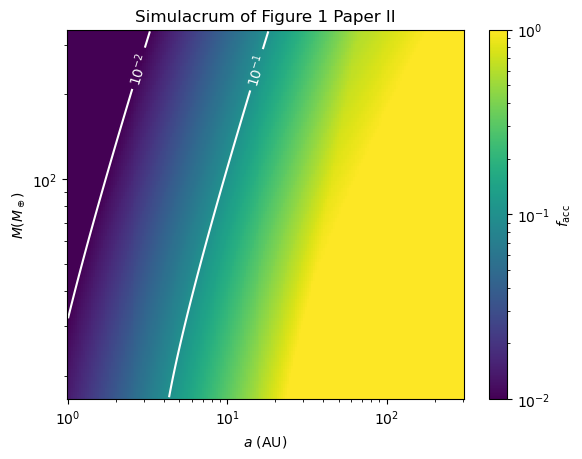

In [8]:
# now we plot as in Figure 1
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'$M (M_\oplus)$')
ax.set_xlabel(r'$a$ (AU)')

# plot facc colormap
norm = mpl.colors.LogNorm(vmin=0.01, vmax=1.0)
im = ax.pcolormesh(np.squeeze(a)/1.5e13, np.squeeze(mass)/5.972e27, facc, shading='nearest', norm=norm)
cbar = fig.colorbar(im)
cbar.set_label(r'$f_{\rm acc}$')

# plto facc contours
CS = ax.contour(np.squeeze(a)/1.5e13, np.squeeze(mass)/5.972e27, facc, levels=[0.01, 0.1, 1.0], colors='w')
fmt = mpl.ticker.LogFormatterMathtext()
fmt.create_dummy_axis()
ax.clabel(CS, CS.levels, fmt=fmt)

ax.set_title('Simulacrum of Figure 1 Paper II')

Overall we see a very nice agreement with the upper-left panel of Figure 1 of Paper II, but with this example being orders of magnitude easier in implementation and computation cost. Subtle differences include the fact that $f_{\rm acc}$ reaches a maximum of 1 here instead of $\sim 3$. This is because, we used the default `mode` which ends up evaluating the analytic formula for $f_{\rm acc}$ where the maximum was set as 1 to simplify the expressions while capturing physics up to order unity effects. If we set `mode='tabulated'`, this maximum is not 1, but set by the numerical solutions $\sim 3$ (see below). The other subtlety is that the "data" which was missing in the upper-left of the plot in Paper II, is now present! This is because the Paper used numerical solutions integrating from a fixed outer boundary at $r=H$. In the upper-left regions, the Bondi radius effectively becomes larger than this fiducial outer boundary. `bonditools` however, uses the solutions of Paper I where the outer boundary is placed at infinity -- thus this boundary consideration is not present in these estimates of $f_{\rm acc}$ -- though this could very easily be imposed after-the-fact since we can compute both $H$ and $r_B$ for this disk model. 

Text(0.5, 1.0, '$f_{\\rm acc}$ (mode="tabulated")')

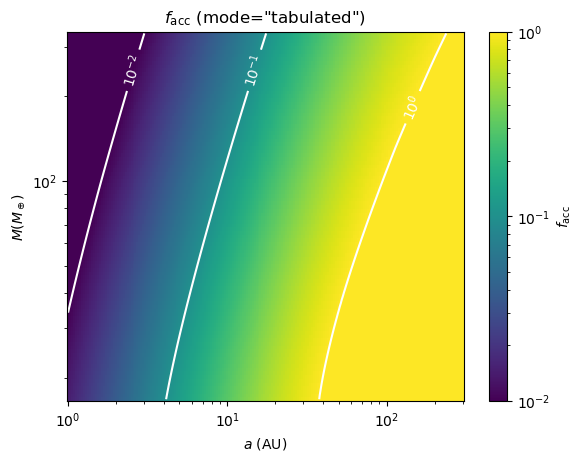

In [9]:
# recompute facc but from tabulated constant opacity numerical solutions
derived_luminosity, facc = bonditools.compute_luminosity_facc_from_cgs(mass = mass,
                                                                       shock_efficiency = shock_efficiency,
                                                                       shock_radius = shock_radius,
                                                                       density = density,
                                                                       temperature = temperature,
                                                                       gamma = gamma,
                                                                       mu = mu,
                                                                       opacity = opacity,
                                                                       mode='tabulated', 
                                                                       extrapolate=True)
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'$M (M_\oplus)$')
ax.set_xlabel(r'$a$ (AU)')

# plot facc colormap
norm = mpl.colors.LogNorm(vmin=0.01, vmax=1.0)
im = ax.pcolormesh(np.squeeze(a)/1.5e13, np.squeeze(mass)/5.972e27, facc, shading='nearest', norm=norm)
cbar = fig.colorbar(im)
cbar.set_label(r'$f_{\rm acc}$')

# plto facc contours
CS = ax.contour(np.squeeze(a)/1.5e13, np.squeeze(mass)/5.972e27, facc, levels=[0.01, 0.1, 1.0], colors='w')
fmt = mpl.ticker.LogFormatterMathtext()
fmt.create_dummy_axis()
ax.clabel(CS, CS.levels, fmt=fmt)

ax.set_title(r'$f_{\rm acc}$ (mode="tabulated")')

# Example 3 - Leveraging the underlying dimensionless functions for specific use-cases
## 3.1 Compute $f_{\rm acc}$ from dimensionless quantities $(\tau_B,\tilde{L}_\infty, \beta)$
While `bonditools` is explicitly designed with `..._from_cgs` functions being the recommended user API, there are a ~dozen private functions which do things under the hood and can be leveraged to simplify some problems. For example, let's try to recreate something like Figure 3 of paper I. In other words, let's compute $f_{\rm acc}$ for a range of ($\tau_B$, $\tilde{L}_\infty$, $\beta$). In principle, we could do this by computing CGS equivalents of many $\tau_B$, $\tilde{L}_\infty$ $\beta$ and using `compute_facc_from_cgs`, but it is far simpler to just compute a grid of ($\tau_B$, $\tilde{L}_\infty$ $\beta$) and run the underlying `_compute_facc_from_dimensionless` function which operates on the dimensionless parameters outright. 

In [10]:
# In this case dimensionless tau, luminosity, and beta are just free parameters.
# Let's let tau and the luminosity range from [0.001, 1000] and look at three 
# slices in beta = 0.001, 1, 1000 as in Figure 3
tau = np.geomspace(0.001, 1000.0, 21)
lum = np.geomspace(0.001, 1000.0, 21)
beta = [0.001, 1.0, 1000.0]

# we need these inputs to be broadcastable
# we could do the broadcasting ourselves and make them explicitly the same shape with something like np.meshgrid:
# tau, lum, beta = np.meshgrid(tau, lum, beta, indexing='ij')
# bonditools.facc_dimensionless(tau, lum, beta)
# but facc_dimensionless will also do broadcasting, so lets just make tau, lum, beta broadcastable
tau = tau[:,None,None]
lum = lum[None,:,None]
beta = np.array(beta)[None, None, :]

# now we just use the facc_dimensionless to compute facc from tau, lum, beta
f = bonditools._compute_facc_from_dimensionless(tau, lum, beta)

# let's check the shape of f, it should be (21,21,3) -- 21 points in tau, 21 points in lum, and 3 points in beta
print(np.shape(f))

(21, 21, 3)


Text(0.5, 1.0, '$\\beta=1000$')

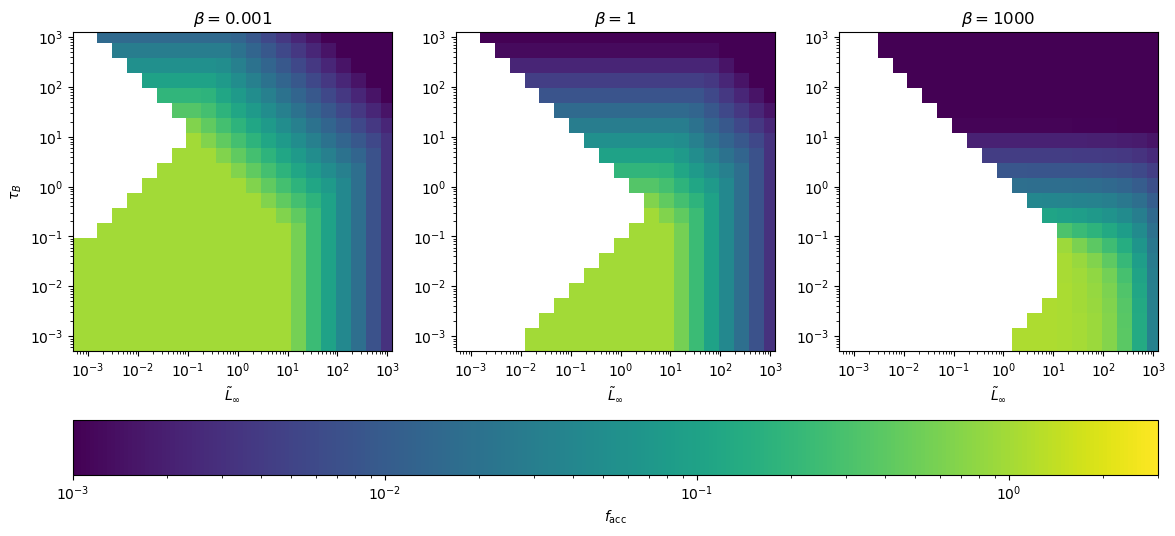

In [11]:
# now let's plot the data in the style of Figure 3
fig, axs = plt.subplots(1,3)
fig.set_figwidth(14)
fig.set_figheight(6)
# use colorbar normalization from Figure 3
norm = mpl.colors.LogNorm(0.001, 3.0)
for i, ax in enumerate(axs):
    # use np.squeeze to remove the broadcast axes
    im = ax.pcolormesh(np.squeeze(lum), np.squeeze(tau), f[:,:,i], norm=norm, shading='nearest')
    ax.set_xlabel(r'$\tilde{L}_\infty$')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_aspect('equal')
cbar = fig.colorbar(im, ax=axs, orientation='horizontal')
cbar.set_label(r'$f_{\rm acc}$')
axs[0].set_ylabel(r'$\tau_B$')
axs[0].set_title(r'$\beta=0.001$')
axs[1].set_title(r'$\beta=1$')
axs[2].set_title(r'$\beta=1000$')

Similar to example 2, we see this effect of applying the analytic formula  for $f_{\rm acc}$ where the maximum is 1. Let's try repeating the exercise also with purely tabulated solutions. There is also no reason we need our resolution to match the coarse resolution of Figure 3, since $f_{\rm acc}$ is coming from an analytic formula or an interpolator so let's try interpolating onto a finer grid at the same time.


Text(0.5, 1.0, '$\\beta=1000$')

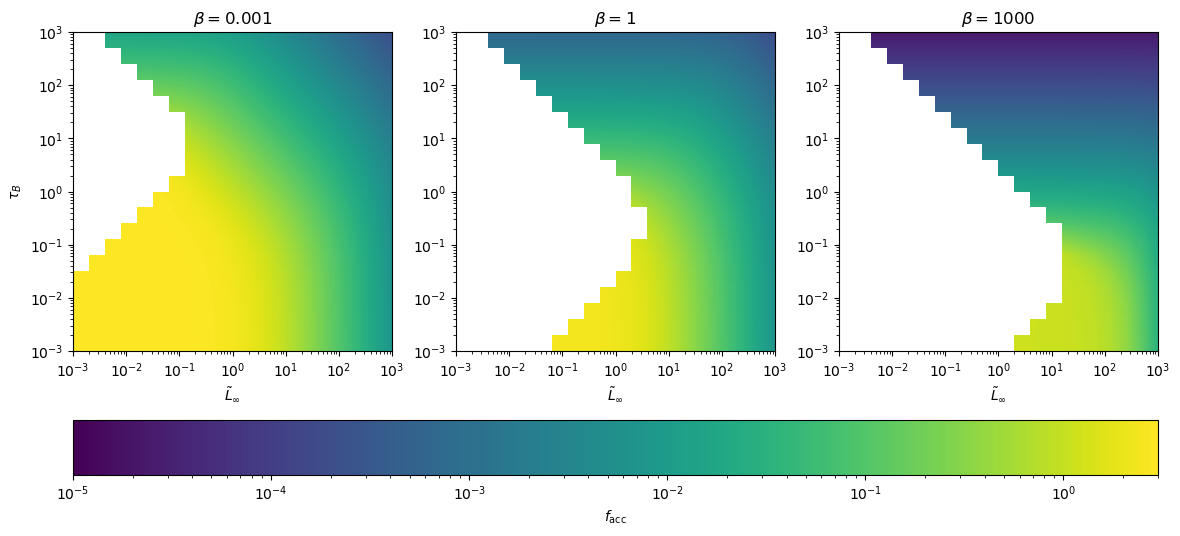

In [12]:
tau = np.geomspace(0.001, 1000.0, 1000)
lum = np.geomspace(0.001, 1000.0, 2000)
beta = [0.001, 1.0, 1000.0]

tau = tau[:,None,None]
lum = lum[None,:,None]
beta = np.array(beta)[None, None, :]

f = bonditools._compute_facc_from_dimensionless(tau, lum, beta, mode='tabulated', interpolation='linear', extrapolate=True)
# now let's plot the data in the style of Figure 3
fig, axs = plt.subplots(1,3)
fig.set_figwidth(14)
fig.set_figheight(6)
norm = mpl.colors.LogNorm(0.00001, 3.0)
for i, ax in enumerate(axs):
    im = ax.pcolormesh(np.squeeze(lum), np.squeeze(tau), f[:,:,i], norm=norm, shading='nearest')
    ax.set_xlabel(r'$\tilde{L}_\infty$')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_aspect('equal')
cbar = fig.colorbar(im, ax=axs, orientation='horizontal')
cbar.set_label(r'$f_{\rm acc}$')
axs[0].set_ylabel(r'$\tau_B$')
axs[0].set_title(r'$\beta=0.001$')
axs[1].set_title(r'$\beta=1$')
axs[2].set_title(r'$\beta=1000$')

## 3.2 Pre-compute a table of $f_{\rm acc}(\tau_B,\eta_s/\tilde{r}_s, \beta)$

For existing code designs that are hard to couple with the simple `compute_facc_from_cgs` and `compute_luminosity_facc_from_cgs` functions, the easiest implementation may be to create a lookup table for $f_{\rm acc}$ That is effectively what `facc.tab` exists as -- it lists $f_{\rm acc}(\tau_B, \tilde{L}_\infty, \beta)$ as a lookup table for `_compute_facc_from_dimensionless`. But if we don't know the luminosity $\tilde{L}_\infty$, in our population synthesis code, we can't really use `facc.tab` without also writing a self-consistent luminosity solver. Perhaps a better option would be to construct a table with $f_{\rm acc}$ returned by `bonditools` after having solved for the luminosity (see example 1.2). We could do this with `compute_luminosity_facc_from_cgs` but our table would be a lookup table over 9 variables, many of them degenerate -- $f_{\rm acc}(M, \rho_\infty, T_\infty,\gamma,\mu, \eta_s, r_s, L_{\rm other}, \kappa)$. 

A cleverer way to do this is to construct a table in the more minimal set of dimensionless parameters. If we look at the source code, `compute_luminosity_facc_from_cgs` is actually just a wrapper for `_compute_luminosity_facc_from_dimensionless` which take 4 parameters:
 - Dimensionless optical depth $\tau_B$
 - Dimensionless adiabatic accretion luminoisty $\tilde{L}_{\rm acc, ad}\equiv \eta_s GM\dot{M}_{\rm ad}/r_s[1/(4\pi r_B^2 ac T^4)]$
 - Dimensionless cooling time $\beta$
 - Dimensionless other luminosity $\tilde{L}_{\rm other} = L_{\rm other}/(4\pi r_B^2 ac T^4)$

So what we can do is pre-compute a table of $f_{\rm acc}(\tau_B, \tilde{L}_{\rm acc, ad}, \beta, \tilde{L}_{\rm other})$. Then at each step in the population synthesis code we could compute $(\tau_B, \tilde{L}_{\rm acc, ad}, \beta, \tilde{L}_{\rm other})$ and lookup $f_{\rm acc}$ in our newly constructed 4-D table. 

For the sake of simplicity here let's take $L_{\rm other} = 0$ so we are making a table of $f_{\rm acc}(\tau_B, \tilde{L}_{\rm acc, ad}, \beta)$. Also since 

$$\tilde{L}_{\rm acc, ad}\equiv \frac{\eta_s GM\dot{M}_{\rm ad}}{r_s}\frac{1}{4\pi r_B^2 ac T^4} = 8\gamma(\gamma-1)\beta\tau_B\left(\frac{2}{5-3\gamma}\right)^{(5-3\gamma)/(2\gamma-2)}\left[\frac{\eta_s}{(r_s/r_B) }\right] \sim \frac{\eta_s}{(r_s/r_B)}\equiv \frac{\eta_s}{\tilde{r}_s}$$

and $\eta_s/\tilde{r}_s\sim r_B/r_s$ is a more physically intuitive quantity (just the ratio of planet radius and Bondi radius) than $\tilde{L}_{\rm acc, ad}$ let's construct a table of dimensionless parameters to be $f_{\rm acc}(\tau_B, \eta_s/\tilde{r}_s, \beta)$. 

For planet-forming conditions $\beta\lesssim 1$, $\tau_B$ can be $\gg 1$ or $\ll 1$, and $r_s < r_B$ so $\eta_s/\tilde{r}_s > 1$. Let's make our table span
 - $\tau_B \in [10^{-3}, 10^3]$
 - $\eta_s/\tilde{r}_s \in [1, 10^5]$
 - $\beta \in [10^{-4}, 1]$


In [13]:
# construct table range and either make broadcastable or explicitly same shape
tau = np.geomspace(0.001, 1000.0, 60)
eta_over_rs = np.geomspace(1.0, 100000.0, 50)
beta = np.geomspace(0.0001, 1.0, 40)

tau, eta_over_rs, beta = np.meshgrid(tau, eta_over_rs, beta, indexing='ij')

We will use the private function `_compute_luminosity_facc_from_dimensionless` to construct $f_{\rm acc}$ so we still need to compute the function input $\tilde{L}_{\rm acc, ad}$ from $\eta_s/\tilde{r}_s$

In [14]:
gamma = 7.0/5.0
q = (2.0/(5.0 - 3.0*gamma))**((5.0 - 3.0*gamma)/(2.0*gamma - 2.0))
lum_acc_ad_dimless = 8.0*gamma*(gamma-1.0)*beta*tau*q*(eta_over_rs)

# now compute f_acc with L_{other} = 0
lum, facc = bonditools._compute_luminosity_facc_from_dimensionless(tau = tau,
                                                                   lum_acc_ad_dimless = lum_acc_ad_dimless,
                                                                   beta = beta,
                                                                   lum_other_dimless = 0.0)

# and we can save our data table in whatever format
# let's save it like facc.tab in ASCII format with 4 columns
# column 1 | column 2 | column 3 | column 4
#   tau    |  eta/rs  |   beta   |  f_acc 
output = np.stack([tau.ravel(), eta_over_rs.ravel(), beta.ravel(), facc.ravel()])
output = np.transpose(output)
np.savetxt('accretion_luminosity_table.tab', output)

We now have our pre-computed lookup table of $f_{\rm acc}(\tau_B, \eta_s/\tilde{r}_s, \beta)$ and it looks to be the appropriate shape. Let's confirm by checking $f_{\rm acc}$ for a set of parameters where we know what $f_{\rm acc}$ is. If we go back to example 1.2, we have the following parameters:
 - $M = 3.0\times 10^{29}$ g
 - $\eta_s = 1$
 - $r_s = 1.5 \times 10^{10}$ cm
 - $\rho = 3.1\times 10^{-12}$ g/cm$^3$
 - $T = 93$ K
 - $\gamma = 7/5$
 - $\mu = 2.4$
 - $\kappa = 0.4$ cm$^2$/g


For which we had found the self-consistent luminosity and $f_{\rm acc}$ is:
 - $L = 7.3 \times 10^{30}$ erg/s
 - $f_{\rm acc} = 0.16$

Here we can compute the dimensionless parameters,
 - $\tau_B = 2.8  $,
 - $\eta_s/\tilde{r}_s = 150$
 - $\beta = 0.009$

and if we lookup $f_{\rm acc}$ in our table for these parameters we find,


In [15]:
# parameters of a planet where we know to expect f_acc = 0.16
mass = 3.0e29
shock_efficiency = 1.0
shock_radius = 1.5e10
density = 3.1e-12
temperature = 93.0
gamma = 7.0/5.0
mu = 2.4
opacity = 0.4

# convert these parameters to dimensionless lookup parameters
def convert_to_dimensionless(mass, shock_efficiency, shock_radius, density, temperature, gamma, mu, opacity):
    cs = np.sqrt(gamma * bonditools.KB_CGS * temperature / (mu * bonditools.MP_CGS))
    rbondi = 0.5 * bonditools.G_CGS * mass / cs**2
    tau = density * opacity * rbondi
    beta = (0.25 * density * cs**3 / (gamma * (gamma - 1.0) * bonditools.A_RAD_CGS * bonditools.C_CGS * temperature**4 * tau))
    eta_over_rs = shock_efficiency * rbondi / shock_radius
    return tau, eta_over_rs, beta

p1, p2, p3 = convert_to_dimensionless(mass = mass,
                                      shock_efficiency = shock_efficiency,
                                      shock_radius = shock_radius,
                                      density = density,
                                      temperature = temperature,
                                      gamma = gamma,
                                      mu = mu,
                                      opacity = opacity)

# now lookup f_acc from the dimensionless parameters
tau_arg = np.nanargmin(np.abs(tau[:,0,0] - p1))
eta_over_rs_arg = np.nanargmin(np.abs(eta_over_rs[0,:,0] - p2))
beta_arg = np.nanargmin(np.abs(beta[0,0,:] - p3))

print('when we lookup f_acc for \ntau = %g, eta/rs = %g, beta=%g, \nwe find f_acc = %g' %(p1, p2, p3, facc[tau_arg, eta_over_rs_arg, beta_arg]))

when we lookup f_acc for 
tau = 2.77226, eta/rs = 149.046, beta=0.00881667, 
we find f_acc = 0.161887


And indeed we find the correct value of $f_{\rm acc}$ from our newly constructed lookup table! We can save our table to whatever format. Below it is saved akin to `facc.tab`.

In [16]:
# save the data table in whatever format we like
# let's save it like facc.tab in ASCII format with 4 columns
# column 1 | column 2 | column 3 | column 4
#   tau    |  eta/rs  |   beta   |  f_acc 
output = np.stack([tau.ravel(), eta_over_rs.ravel(), beta.ravel(), facc.ravel()])
output = np.transpose(output)
np.savetxt('accretion_luminosity_table.tab', output)

Then this table may be read directly into a population synthesis code and used to evaluate $f_{\rm acc}$ without needing to do any solving for the self-consistent luminosity since we already did this in constructing the lookup table.

To summarize, the procedure for implementing $f_{\rm acc}$ via a lookup table is as follows:
 1. Decide the variables you would like to use for lookup (e.g. $\tau_B, \eta_s/\tilde{r}_s, \beta$)
 2. Define a fiducial grid of those variables
 3. Convert variables to inputs for `_compute_luminosity_facc_from_dimensionless` ($\tau_B, \tilde{L}_{\rm acc, ad}, \beta, \tilde{L}_{\rm other}$)
 4. Run `_compute_luminosity_facc_from_dimensionless` to get $f_{\rm acc}$ and save as a lookup table
 5. Load the lookup table from within your population synthesis code
 6. Each timestep, compute the variables for the planet ($\tau_B, \eta_s/\tilde{r}_s, \beta$)
 7. Lookup $f_{\rm acc}$ for the computed ($\tau_B, \eta_s/\tilde{r}_s, \beta$)
 8. Multiply the accretion rate by this newly found $f_{\rm acc}$